# LDPC logical error rate vs physical error rate (Stim)

This notebook builds **CSS LDPC codes** (via hypergraph product), compiles **Stim stabilizer measurement circuits**, and estimates logical error rate using `sinter` + `pymatching`.

We sweep physical error rate `p` for multiple code sizes (lift factors `L`) and plot logical error rate curves.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import stim
import sinter

In [3]:
def gf2_row_echelon(a: np.ndarray):
    m = (a.copy() % 2).astype(np.uint8)
    rows, cols = m.shape
    pivot_cols = []
    r = 0
    for c in range(cols):
        pivot = None
        for rr in range(r, rows):
            if m[rr, c]:
                pivot = rr
                break
        if pivot is None:
            continue
        if pivot != r:
            m[[r, pivot]] = m[[pivot, r]]
        for rr in range(rows):
            if rr != r and m[rr, c]:
                m[rr] ^= m[r]
        pivot_cols.append(c)
        r += 1
        if r == rows:
            break
    return m, pivot_cols


def gf2_rank(a: np.ndarray) -> int:
    _, piv = gf2_row_echelon(a)
    return len(piv)


def gf2_nullspace(a: np.ndarray) -> np.ndarray:
    ref, piv = gf2_row_echelon(a)
    rows, cols = ref.shape
    free = [c for c in range(cols) if c not in piv]
    if len(free) == 0:
        return np.zeros((0, cols), dtype=np.uint8)

    basis = []
    for f in free:
        v = np.zeros(cols, dtype=np.uint8)
        v[f] = 1
        for r, pc in enumerate(piv):
            if ref[r, f]:
                v[pc] = 1
        basis.append(v)
    return np.array(basis, dtype=np.uint8)


def find_logical_x(Hx: np.ndarray, Hz: np.ndarray) -> np.ndarray:
    """Find one non-trivial logical X in ker(Hx) minus rowspace(Hz)."""
    kernel_basis = gf2_nullspace(Hx)
    r_hz = gf2_rank(Hz)
    for v in kernel_basis:
        combined = np.vstack([Hz % 2, v[np.newaxis, :]]) % 2
        if gf2_rank(combined) > r_hz:
            return v.astype(np.uint8)
    raise ValueError("No logical X found; try another random code instance.")

In [4]:
def hypergraph_product(H1: np.ndarray, H2: np.ndarray):
    r1, n1 = H1.shape
    r2, n2 = H2.shape
    Ir1 = np.eye(r1, dtype=np.uint8)
    Ir2 = np.eye(r2, dtype=np.uint8)
    In1 = np.eye(n1, dtype=np.uint8)
    In2 = np.eye(n2, dtype=np.uint8)

    Hx = np.block([np.kron(H1, In2), np.kron(Ir1, H2.T)]) % 2
    Hz = np.block([np.kron(In1, H2), np.kron(H1.T, Ir2)]) % 2
    return Hx.astype(np.uint8), Hz.astype(np.uint8)


def circulant_perm(L: int, s: int) -> np.ndarray:
    I = np.eye(L, dtype=np.uint8)
    return np.roll(I, s % L, axis=1)


def qc_parity_from_shifts(shift_mat: np.ndarray, L: int) -> np.ndarray:
    br, bc = shift_mat.shape
    blocks = []
    for i in range(br):
        row_blocks = []
        for j in range(bc):
            s = int(shift_mat[i, j])
            if s < 0:
                row_blocks.append(np.zeros((L, L), dtype=np.uint8))
            else:
                row_blocks.append(circulant_perm(L, s))
        blocks.append(row_blocks)
    return (np.block(blocks) % 2).astype(np.uint8)


def random_shift_matrix(mask: np.ndarray, L: int, rng: np.random.Generator) -> np.ndarray:
    S = np.full(mask.shape, -1, dtype=int)
    ones = np.argwhere(mask == 1)
    for i, j in ones:
        S[i, j] = int(rng.integers(0, L))
    return S


def build_hgp_for_lift(L: int, seed: int = 0, max_tries: int = 80, min_k: int = 1):
    base_mask = np.array(
        [
            [1, 1, 0, 1, 0, 1],
            [0, 1, 1, 0, 1, 1],
            [1, 0, 1, 1, 1, 0],
        ],
        dtype=np.uint8,
    )

    rng = np.random.default_rng(seed)
    for _ in range(max_tries):
        shifts = random_shift_matrix(base_mask, L, rng)
        H = qc_parity_from_shifts(shifts, L)
        Hx, Hz = hypergraph_product(H, H)
        k = Hx.shape[1] - gf2_rank(Hx) - gf2_rank(Hz)
        if k >= min_k:
            return H, Hx, Hz, int(k)

    raise ValueError(f"Could not find non-trivial code for L={L}.")

In [5]:
def css_x_memory_circuit(Hx: np.ndarray, Hz: np.ndarray, p: float) -> stim.Circuit:
    """One-round X-memory experiment using Z stabilizer checks from Hx."""
    r, n = Hx.shape
    data = list(range(n))
    anc = list(range(n, n + r))

    c = stim.Circuit()
    c.append("R", data + anc)
    c.append("X_ERROR", data, float(p))

    for i, row in enumerate(Hx):
        support = [j for j, bit in enumerate(row) if bit]
        a = anc[i]
        c.append("H", [a])
        for q in support:
            c.append("CZ", [a, q])
        c.append("H", [a])
        c.append("M", [a])
        c.append("DETECTOR", [stim.target_rec(-1)])

    c.append("M", data)

    logical_vec = find_logical_x(Hx, Hz)
    logical_support = [j for j, bit in enumerate(logical_vec) if bit]
    c.append(
        "OBSERVABLE_INCLUDE",
        [stim.target_rec(-(n - q)) for q in sorted(logical_support)],
        0,
    )
    return c

In [10]:
# Sweep settings
sizes = [3, 5, 7]              # QC lift factors (larger => larger code)
p_values = np.geomspace(0.002, 0.06, 7)
max_shots_per_point = 6_000
max_errors_per_point = 10

# Build one task per (size, p)
tasks = []
for L in sizes:
    _, Hx, Hz, k = build_hgp_for_lift(L=L, seed=2026 + L, min_k=1)
    n_phys = int(Hx.shape[1])
    for p in p_values:
        circuit = css_x_memory_circuit(Hx=Hx, Hz=Hz, p=float(p))
        tasks.append(
            sinter.Task(
                circuit=circuit,
                json_metadata={
                    "L": int(L),
                    "p": float(p),
                    "k": int(k),
                    "n_phys": n_phys,
                },
            )
        )

print(f"Built {len(tasks)} tasks across {len(sizes)} code sizes.")


def collect_one_task(task: sinter.Task):
    last_error = None
    for decoder in ["pymatching", "vacuous"]:
        try:
            sample = sinter.collect(
                tasks=[task],
                decoders=[decoder],
                num_workers=4,
                max_shots=max_shots_per_point,
                max_errors=max_errors_per_point,
                print_progress=False,
            )[0]
            return sample, decoder
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"All decoders failed for task metadata={task.json_metadata}") from last_error


records = []
for task in tasks:
    sample, decoder_used = collect_one_task(task)
    md = dict(sample.json_metadata)
    records.append(
        {
            "L": int(md["L"]),
            "p": float(md["p"]),
            "k": int(md["k"]),
            "n_phys": int(md["n_phys"]),
            "decoder": decoder_used,
            "shots": int(sample.shots),
            "errors": int(sample.errors),
            "p_logical": float(sample.errors / sample.shots if sample.shots else 0.0),
        }
    )

records = sorted(records, key=lambda r: (r["L"], r["p"]))
print(f"Finished {len(records)} points.")
print("Decoder usage:", {d: sum(r['decoder'] == d for r in records) for d in ["pymatching", "vacuous"]})

Built 21 tasks across 3 code sizes.
Finished 21 points.
Decoder usage: {'pymatching': 0, 'vacuous': 21}


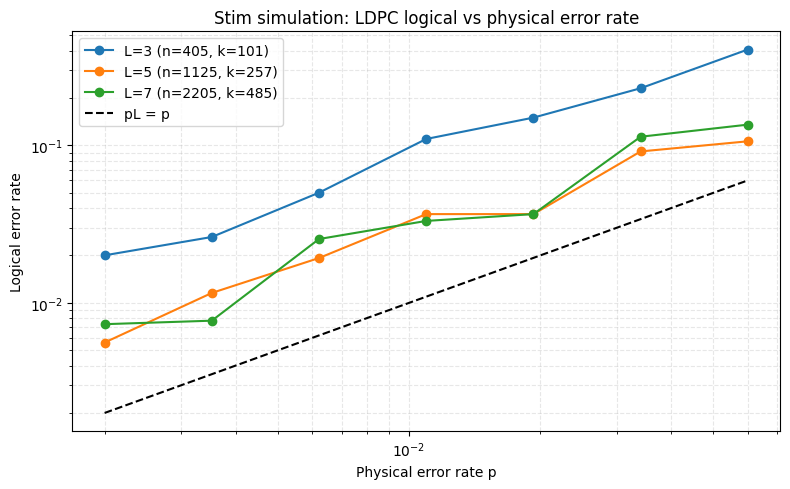

L=3, n=405, k=101, p=0.0020 -> pL=0.02005 (26/1297)
L=3, n=405, k=101, p=0.0035 -> pL=0.02621 (34/1297)
L=3, n=405, k=101, p=0.0062 -> pL=0.05012 (65/1297)
L=3, n=405, k=101, p=0.0110 -> pL=0.1099 (30/273)
L=3, n=405, k=101, p=0.0193 -> pL=0.1502 (41/273)
L=3, n=405, k=101, p=0.0340 -> pL=0.2308 (63/273)
L=3, n=405, k=101, p=0.0600 -> pL=0.4066 (111/273)
L=5, n=1125, k=257, p=0.0020 -> pL=0.005601 (13/2321)
L=5, n=1125, k=257, p=0.0035 -> pL=0.01157 (15/1297)
L=5, n=1125, k=257, p=0.0062 -> pL=0.01928 (25/1297)
L=5, n=1125, k=257, p=0.0110 -> pL=0.03663 (10/273)
L=5, n=1125, k=257, p=0.0193 -> pL=0.03663 (10/273)
L=5, n=1125, k=257, p=0.0340 -> pL=0.09158 (25/273)
L=5, n=1125, k=257, p=0.0600 -> pL=0.1062 (29/273)
L=7, n=2205, k=485, p=0.0020 -> pL=0.007324 (17/2321)
L=7, n=2205, k=485, p=0.0035 -> pL=0.00771 (10/1297)
L=7, n=2205, k=485, p=0.0062 -> pL=0.02544 (33/1297)
L=7, n=2205, k=485, p=0.0110 -> pL=0.03315 (43/1297)
L=7, n=2205, k=485, p=0.0193 -> pL=0.03663 (10/273)
L=7, n=2205

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for L in sizes:
    pts = [r for r in records if r["L"] == L]
    if not pts:
        continue
    xs = [r["p"] for r in pts]
    ys = [max(r["p_logical"], 1e-12) for r in pts]
    n_phys = pts[0]["n_phys"]
    k = pts[0]["k"]
    ax.plot(xs, ys, marker="o", label=f"L={L} (n={n_phys}, k={k})")

all_ps = sorted({r["p"] for r in records})
ax.plot(all_ps, all_ps, linestyle="--", color="black", linewidth=1.5, label="pL = p")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Physical error rate p")
ax.set_ylabel("Logical error rate")
ax.set_title("Stim simulation: LDPC logical vs physical error rate")
ax.grid(True, which="both", ls="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for r in records:
    print(
        f"L={r['L']}, n={r['n_phys']}, k={r['k']}, p={r['p']:.4f} -> "
        f"pL={r['p_logical']:.4g} ({r['errors']}/{r['shots']})"
    )